In [1]:
# Import agrifoodpy to use accessors (e.g. land.plot() )
import agrifoodpy
import xarray as xr
import numpy as np
from agrifoodpy_data.land import ONS_LAD_MAY_2025_UK_BUC_1000 as land_data
from agrifoodpy_data.population import UK_ONS_MYE24UK as pop_data

import matplotlib.pyplot as plt

# Land data

LAD (Local Authority Districts) boundary maps are available in agrifoodpy_data
as a single array dataset which is aligned to the BNG coordinate system used in
all agrifoodpy land datasets

```python
from agrifoodpy_data.land import ONS_LAD_MAY_2025_UK_BUC_1000
```

The `ID` dimension maps the different LADs to the value used in the two dimensional segment map.
The `LAD25CD` and `LAD25NM` label coordinates are aligned with `ID` and use standardised
names and [GSS codes](https://en.wikipedia.org/wiki/GSS_coding_system) for easier matching with other
spatial dependent datasets.


In [2]:
land_data

<xarray.Dataset> Size: 6MB
Dimensions:     (y: 1214, x: 656, ID: 361)
Coordinates:
  * y           (y) float64 10kB 500.0 1.5e+03 2.5e+03 ... 1.212e+06 1.214e+06
  * x           (x) float64 5kB 500.0 1.5e+03 2.5e+03 ... 6.545e+05 6.555e+05
  * ID          (ID) int64 3kB 0 1 2 3 4 5 6 7 ... 354 355 356 357 358 359 360
    LAD25CD     (ID) <U9 13kB 'E06000001' 'E06000002' ... 'W06000024'
    LAD25NM     (ID) <U36 52kB 'Hartlepool' 'Middlesbrough' ... 'Merthyr Tydfil'
Data variables:
    Boundaries  (y, x) float64 6MB nan nan nan nan nan ... nan nan nan nan nan

<Axes: >

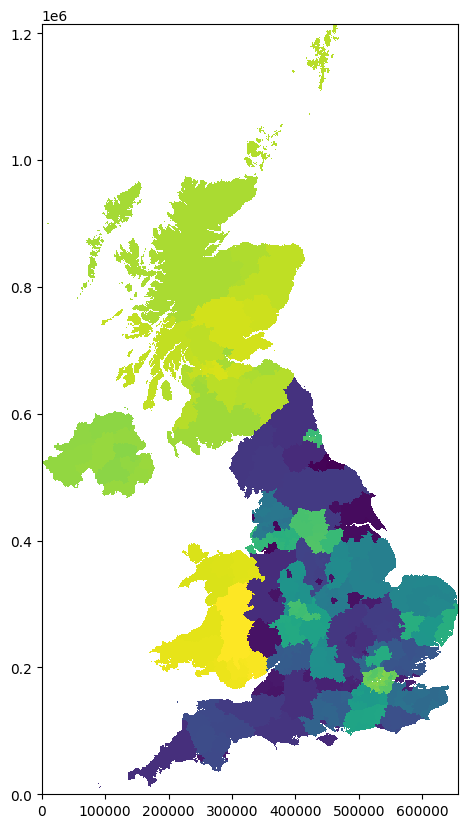

In [3]:
f, ax = plt.subplots(figsize=(10, 10))
land_data["Boundaries"].land.plot(ax=ax)

In [4]:
# Get segment map ID or name

name, code = "Highland", "S12000017"
# name, code = "York", "E06000014"

In [5]:
lad_ID = land_data["ID"].where(land_data["LAD25NM"] == name, drop=True).item()
lad_ID

314.0

In [6]:
lad_ID = land_data["ID"].where(land_data["LAD25CD"] == code, drop=True).item()
lad_ID

314.0

<Axes: >

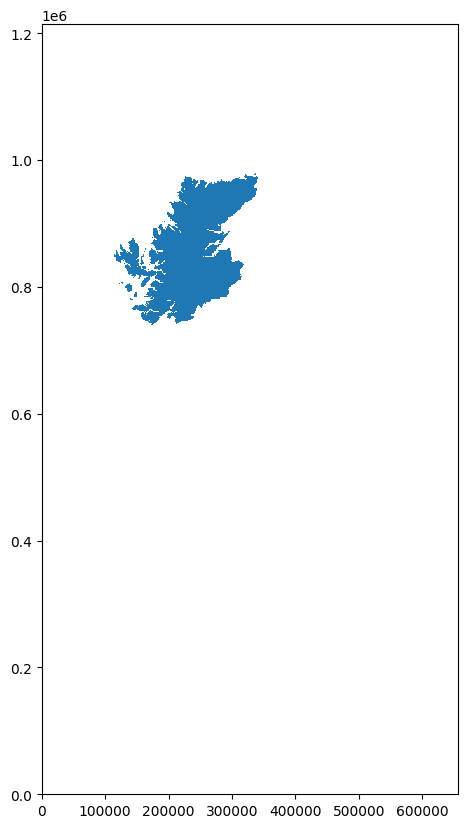

In [7]:
# Get boolean mask with the boundaries of York
f, ax = plt.subplots(figsize=(10, 10))
lad_mask = land_data["Boundaries"].where(land_data["Boundaries"] == lad_ID)
lad_mask.land.plot(ax=ax)

<Axes: >

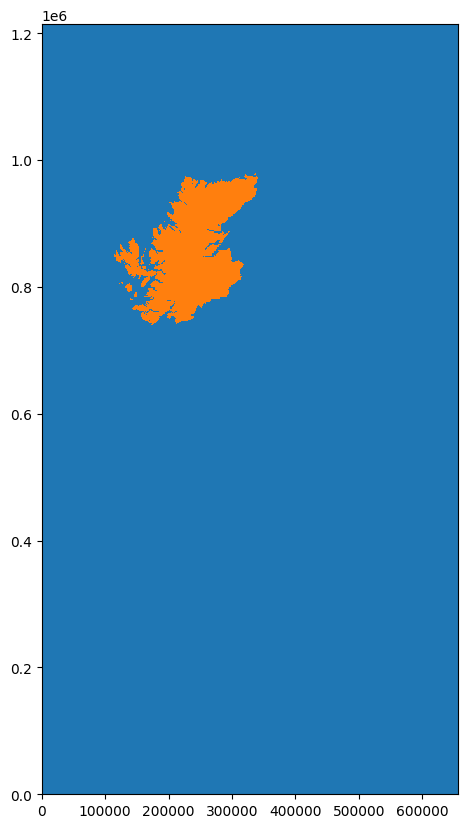

In [8]:
# Or, alternatively for a boolean mask,
# use the equality operator to create a boolean mask directly:
f, ax = plt.subplots(figsize=(10, 10))
LAD_mask_alt = land_data["Boundaries"] == lad_ID
LAD_mask_alt.land.plot(ax=ax)

# Population data

Population data for different national and sub-national administrative units is available from agrifoodpy_data via:

```python
from agrifoodpy_data.population import UK_ONS_MYE24UK
```

The DataArray contains total population, indexed by area GSS code (see Land data).
Optionally, the area unit names are also available as a label coordinate for indexing.
This DataArray is significantly easier to work with given that `xr.DataArray.sel()` directly returns the data for a specific `Code` or `Name` value


In [9]:
pop_data

<xarray.Dataset> Size: 76kB
Dimensions:   (Code: 404)
Coordinates:
  * Code      (Code) <U9 15kB 'K02000001' 'K03000001' ... 'N09000011'
    Name      (Code) <U36 58kB 'UNITED KINGDOM' ... 'Ards and North Down'
Data variables:
    All ages  (Code) int64 3kB 69281437 67353582 61806682 ... 183115 165415

In [10]:
pop_data.sel(Code=code)

<xarray.Dataset> Size: 188B
Dimensions:   ()
Coordinates:
    Name      <U36 144B 'Highland'
    Code      <U9 36B 'S12000017'
Data variables:
    All ages  int64 8B 237290

# Matching

The code below shows whether all LADs in the segment map have population data.

In [11]:
id_list = np.arange(len(land_data.LAD25CD.values))
missing_list = id_list[~np.isin(land_data.LAD25CD.values, pop_data.Code.values)]

land_data.sel(ID=missing_list)

<xarray.Dataset> Size: 6MB
Dimensions:     (y: 1214, x: 656, ID: 2)
Coordinates:
  * y           (y) float64 10kB 500.0 1.5e+03 2.5e+03 ... 1.212e+06 1.214e+06
  * x           (x) float64 5kB 500.0 1.5e+03 2.5e+03 ... 6.545e+05 6.555e+05
  * ID          (ID) int64 16B 261 262
    LAD25CD     (ID) <U9 72B 'E08000038' 'E08000039'
    LAD25NM     (ID) <U36 288B 'Barnsley' 'Sheffield'
Data variables:
    Boundaries  (y, x) float64 6MB nan nan nan nan nan ... nan nan nan nan nan

So there are two local authorities in the land data that are not present in the population data. These are:
- E08000038 - Barnsley
- E08000039 - Sheffield

Which changed their common boundary in 2024 according to [this decree](https://www.legislation.gov.uk/uksi/2024/1328/made) 